In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt, iirnotch
from sklearn.preprocessing import StandardScaler

In [2]:
labels_df = pd.read_csv("labels.csv")
eeg_files = glob.glob("MI CSV/*.csv")

In [3]:
eeg_files_sorted = sorted(
    eeg_files,
    key=lambda x: int(
        os.path.basename(x)
        .replace("cellula_MI_data_", "")
        .replace(".csv", "")
    )
)

labels_used = labels_df.iloc[:len(eeg_files_sorted)]

matched_df = pd.DataFrame({
    "file_path": eeg_files_sorted,
    "label": labels_used["label"].values
})

print("Matched samples:", len(matched_df))
matched_df.to_csv("matched_samples.csv", index=False)

Matched samples: 2160


In [4]:
def bandpass_filter(data,
                    lowcut,
                    highcut,
                    fs,
                    order=4):

    nyquist = 0.5 * fs

    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(
        order,
        [low, high],
        btype="band"
    )

    return filtfilt(b, a, data)

In [5]:
def notch_filter(data,
                 notch_freq,
                 fs,
                 q=30):

    b, a = iirnotch(
        notch_freq,
        q,
        fs
    )

    return filtfilt(b, a, data)

In [6]:
channels = ["FZ", "C3", "CZ", "C4"]

def preprocess_trial(df, fs):
    
    processed = df.copy()

    # Band-pass filter
    for ch in channels:
        processed[ch] = bandpass_filter(
            processed[ch],
            8,
            30,
            fs
        )

    # Notch filter
    for ch in channels:
        processed[ch] = notch_filter(
            processed[ch],
            50,
            fs
        )

    # Common Average Reference (CAR)
    reference = processed[channels].mean(axis=1)

    for ch in channels:
        processed[ch] = processed[ch] - reference

    return processed

In [7]:
processed_trials = []
processed_labels = []

for idx, row in matched_df.iterrows():

    file_path = row["file_path"]
    label = row["label"]

    try:
        trial_df = pd.read_csv(file_path)

        processed_df = preprocess_trial(
            trial_df,
            fs
        )

        processed_trials.append(processed_df)
        processed_labels.append(label)

        if (idx + 1) % 100 == 0:
            print(f"Processed {idx + 1}/{len(matched_df)}")

    except Exception as e:
        print(f"Error in {file_path}: {e}")

print("\nFinished!")
print("Processed trials:", len(processed_trials))

Error in MI CSV\cellula_MI_data_1.csv: name 'fs' is not defined
Error in MI CSV\cellula_MI_data_2.csv: name 'fs' is not defined
Error in MI CSV\cellula_MI_data_3.csv: name 'fs' is not defined
Error in MI CSV\cellula_MI_data_4.csv: name 'fs' is not defined
Error in MI CSV\cellula_MI_data_5.csv: name 'fs' is not defined
Error in MI CSV\cellula_MI_data_6.csv: name 'fs' is not defined
Error in MI CSV\cellula_MI_data_7.csv: name 'fs' is not defined
Error in MI CSV\cellula_MI_data_8.csv: name 'fs' is not defined
Error in MI CSV\cellula_MI_data_9.csv: name 'fs' is not defined
Error in MI CSV\cellula_MI_data_10.csv: name 'fs' is not defined
Error in MI CSV\cellula_MI_data_11.csv: name 'fs' is not defined
Error in MI CSV\cellula_MI_data_12.csv: name 'fs' is not defined
Error in MI CSV\cellula_MI_data_13.csv: name 'fs' is not defined
Error in MI CSV\cellula_MI_data_14.csv: name 'fs' is not defined
Error in MI CSV\cellula_MI_data_15.csv: name 'fs' is not defined
Error in MI CSV\cellula_MI_data_16

Error in MI CSV\cellula_MI_data_27.csv: name 'fs' is not defined
Error in MI CSV\cellula_MI_data_28.csv: name 'fs' is not defined
Error in MI CSV\cellula_MI_data_29.csv: name 'fs' is not defined
Error in MI CSV\cellula_MI_data_30.csv: name 'fs' is not defined
Error in MI CSV\cellula_MI_data_31.csv: name 'fs' is not defined
Error in MI CSV\cellula_MI_data_32.csv: name 'fs' is not defined
Error in MI CSV\cellula_MI_data_33.csv: name 'fs' is not defined
Error in MI CSV\cellula_MI_data_34.csv: name 'fs' is not defined
Error in MI CSV\cellula_MI_data_35.csv: name 'fs' is not defined
Error in MI CSV\cellula_MI_data_36.csv: name 'fs' is not defined
Error in MI CSV\cellula_MI_data_37.csv: name 'fs' is not defined
Error in MI CSV\cellula_MI_data_38.csv: name 'fs' is not defined
Error in MI CSV\cellula_MI_data_39.csv: name 'fs' is not defined
Error in MI CSV\cellula_MI_data_40.csv: name 'fs' is not defined
Error in MI CSV\cellula_MI_data_41.csv: name 'fs' is not defined
Error in MI CSV\cellula_M

In [8]:
print(processed_trials[0].head())
print("Label:", processed_labels[0])

IndexError: list index out of range

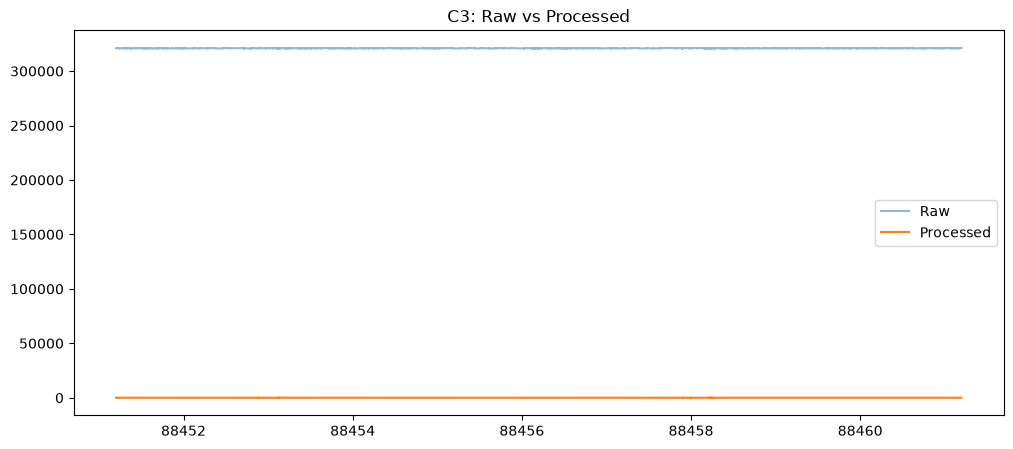

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(sample_df["Time"],
         sample_df["C3"],
         label="Raw",
         alpha=0.5)

plt.plot(processed_trials[0]["Time"],
         processed_trials[0]["C3"],
         label="Processed")

plt.legend()
plt.title("C3: Raw vs Processed")
plt.show()

In [ ]:
epoch_length = int(fs)

In [ ]:
def create_epochs(df, epoch_length):

    epochs = []

    for start in range(
        0,
        len(df) - epoch_length + 1,
        epoch_length
    ):
        epoch = df.iloc[
            start:start + epoch_length
        ].copy()

        epochs.append(epoch)

    return epochs

In [ ]:
all_epochs = []
all_epoch_labels = []

for trial, label in zip(
    processed_trials,
    processed_labels
):

    trial_epochs = create_epochs(
        trial,
        epoch_length
    )

    all_epochs.extend(trial_epochs)

    all_epoch_labels.extend(
        [label] * len(trial_epochs)
    )

In [ ]:
print("Total epochs:", len(all_epochs))

Total epochs: 21600


In [ ]:
channels = ["FZ", "C3", "CZ", "C4"]

def baseline_correction(epoch):

    corrected = epoch.copy()
    
    for ch in channels:
        baseline = corrected[ch].mean()
        corrected[ch] = (
            corrected[ch] - baseline
        )

    return corrected

In [ ]:
corrected_epochs = []

for epoch in all_epochs:
    corrected_epochs.append(
        baseline_correction(epoch)
    )

In [ ]:
from sklearn.preprocessing import StandardScaler
normalized_epochs = []

for epoch in corrected_epochs:
    scaler = StandardScaler()
    normalized = epoch.copy()
    normalized[channels] = scaler.fit_transform(
        normalized[channels]
    )

    normalized_epochs.append(
        normalized
    )

In [ ]:
normalized_epochs[0][channels].describe()

,FZ,C3,CZ,C4
count,250.000000,250.000000,250.000000,2.500000e+02
mean,0.000000,0.000000,0.000000,-2.842171e-17
std,1.002006,1.002006,1.002006,1.002006e+00
min,-2.108816,-2.003652,-7.944341,-7.930834e+00
25%,-0.184039,-0.184212,-0.122383,6.176248e-02
50%,-0.094157,-0.113479,0.083931,1.091251e-01
75%,-0.024799,-0.024107,0.308078,1.499597e-01
max,7.912931,7.968621,2.038933,2.064019e+00


In [ ]:
import pickle

processed_dataset = {
    "trials": processed_trials,
    "labels": processed_labels,
    "epochs": normalized_epochs,
    "epoch_labels": all_epoch_labels
}

with open("processed_eeg_dataset.pkl", "wb") as f:
    pickle.dump(processed_dataset, f)

print("Dataset saved as processed_eeg_dataset.pkl")

print("Number of trials:", len(processed_trials))
print("Number of labels:", len(processed_labels))
print("Number of epochs:", len(normalized_epochs))
print("Number of epoch labels:", len(all_epoch_labels))

Dataset saved as processed_eeg_dataset.pkl
Number of trials: 2160
Number of labels: 2160
Number of epochs: 21600
Number of epoch labels: 21600
